In [1]:
import optuna
from optuna.samplers import TPESampler
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
x_train = pd.read_csv("x_train.csv")
y_train = pd.read_csv("y_train.csv")
x_test = pd.read_csv("x_test.csv")
y_test = pd.read_csv("y_test.csv")

print("训练集大小:", len(x_train))
print("外部验证集大小:", len(x_test))

训练集大小: 921
外部验证集大小: 231


In [3]:
import joblib
best_model = joblib.load('RandomForest_regression_model.pkl')
y_pred_train = best_model.predict(x_train)
y_pred_test = best_model.predict(x_test)

y_pred_test = best_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\n测试集性能:")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"决定系数 (R²): {r2:.4f}")



测试集性能:
均方误差 (MSE): 19.4063
均方根误差 (RMSE): 4.4053
平均绝对误差 (MAE): 2.6505
决定系数 (R²): 0.7591


In [4]:
y_pred_train = best_model.predict(x_train)

mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_train, y_pred_train)
r2 = r2_score(y_train, y_pred_train)

print("\ntrain性能:")
print(f"均方误差 (MSE): {mse:.4f}")
print(f"均方根误差 (RMSE): {rmse:.4f}")
print(f"平均绝对误差 (MAE): {mae:.4f}")
print(f"决定系数 (R²): {r2:.4f}")



train性能:
均方误差 (MSE): 1.6729
均方根误差 (RMSE): 1.2934
平均绝对误差 (MAE): 0.8424
决定系数 (R²): 0.9791


/home/haha/anaconda3/envs/ml/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/haha/anaconda3/envs/ml/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/haha/anaconda3/envs/ml/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/haha/anaconda3/envs/ml/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was

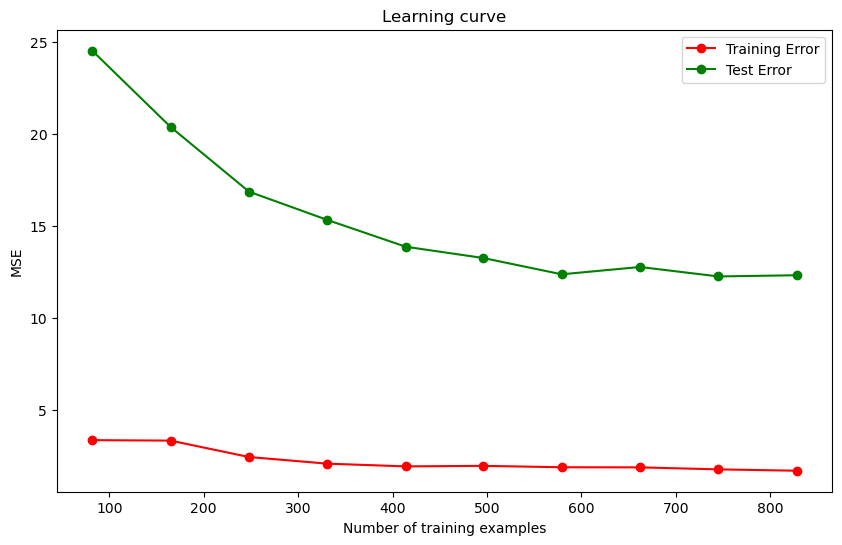

In [5]:
def plot_learning_curve(model, X, y):
   
    from sklearn.model_selection import learning_curve
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=10, scoring='neg_mean_squared_error',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Error')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Test Error')
    plt.xlabel('Number of training examples')
    plt.ylabel('MSE')
    plt.title('Learning curve')
    plt.legend(loc='best')
    plt.show()

plot_learning_curve(best_model, x_train, y_train)

In [ ]:
import shap
explainer = shap.Explainer(best_model, x_train)
shap_values = tree_explainer(x_train)
shap.plots.beeswarm(shap_values)

 94%|=================== | 868/921 [00:12<00:00]       

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 14.288469, while the model output was 14.784291. If this difference is acceptable you can set check_additivity=False to disable this check.

In [7]:
y_pred_train_pd = pd.DataFrame()
y_pred_train_pd['S(mg/g)_pred'] = y_pred_train
y_pred_train_pd

,S(mg/g)_pred
0,16.062932
1,0.353744
2,10.482821
3,1.772821
4,0.301111
...,...
916,11.977769
917,3.513910
918,4.313372
919,1.946282


In [8]:
y_pred_test_pd = pd.DataFrame()
y_pred_test_pd['S(mg/g)_pred'] = y_pred_test
y_pred_test_pd

,S(mg/g)_pred
0,10.512436
1,0.886667
2,3.243590
3,0.449615
4,10.509110
...,...
226,0.386026
227,23.022564
228,10.534013
229,1.415013


In [9]:
XGB_train_result = x_train.join(y_train).join(y_pred_train_pd)
XGB_train_result.to_csv('RF_train_result.csv')
XGB_test_result = x_test.join(y_test).join(y_pred_test_pd)
XGB_test_result.to_csv('RF_test_result.csv')